In [9]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load


# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
import requests
import pandas as pd
import json
import time
import numpy as np
from datetime import datetime
from homeharvest import scrape_property
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.metrics import mean_absolute_percentage_error
import joblib
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
import seaborn as sns 

for dirname, _, filenames in os.walk("./"):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All"
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

./Project_3.csv
./Project_3.ipynb
./.ipynb_checkpoints/Project_3-checkpoint.ipynb
./.ipynb_checkpoints/Project_3-checkpoint.csv
./data/hello
./data/.ipynb_checkpoints/hello-checkpoint


# 1. Frame the problem
Using the customer description, Define the problem your trying to solve in your own words (remember this is not technial but must be specific so the customer understands the project

In [ ]:
"""
Figure out which people purchased the cog, which means we must find our product market fit
with the data we have
"""

# 2. Get the Data 
Define how you recieved the data (provided, gathered..)

In [ ]:
# Given by teacher

# 3. Explore the Data
Gain insights into the data you have from step 2, making sure to identify any bias

In [5]:
data = pd.read_csv("/home/jupyter-259941/Project_3/Project_3.csv")
data.head()

# Create new columns using boolean logic
data['is_purchased'] = (data['Purchased'] == 1)
data['is_not_purchased'] = (data['Purchased'] == 0)
data['is_returned'] = (data['Purchased'] == -1)
data.head()

,User ID,name,Gender,Age,EstimatedSalary,Purchased,is_purchased,is_not_purchased,is_returned
0,10000,Holly Ruiz,Female,32,133029,0,False,True,False
1,10001,Jesus Gilbert,Female,40,62182,0,False,True,False
2,10002,Rodney Williams,Female,23,16699,1,True,False,False
3,10003,Steven Wright,Female,44,10851,0,False,True,False
4,10004,Brenda Blackwell,Male,52,54327,0,False,True,False


In [25]:
df_pmf = data.copy()
df_pmf['Purchased_Numeric'] = df_pmf['is_purchased'].astype(int)
age_bins = [18, 25, 35, 45, 55, 100]
age_labels = ['18-24', '25-35', '35-45', '45-55', '55+']
df_pmf['Age Group'] = pd.cut(df_pmf['Age'], bins=age_bins, labels=age_labels, right=False)

In [26]:
salary_bins = [0, 30000, 60000, 90000, 120000, 180000]
salary_labels = ['0-30k', '30k-60k', '60k-90k', '90k-120k', '120k+']
df_pmf['Salary Group'] = pd.cut(df_pmf['EstimatedSalary'], bins=salary_bins, 
                                labels=salary_labels, right=False)

<function matplotlib.pyplot.show(close=None, block=None)>

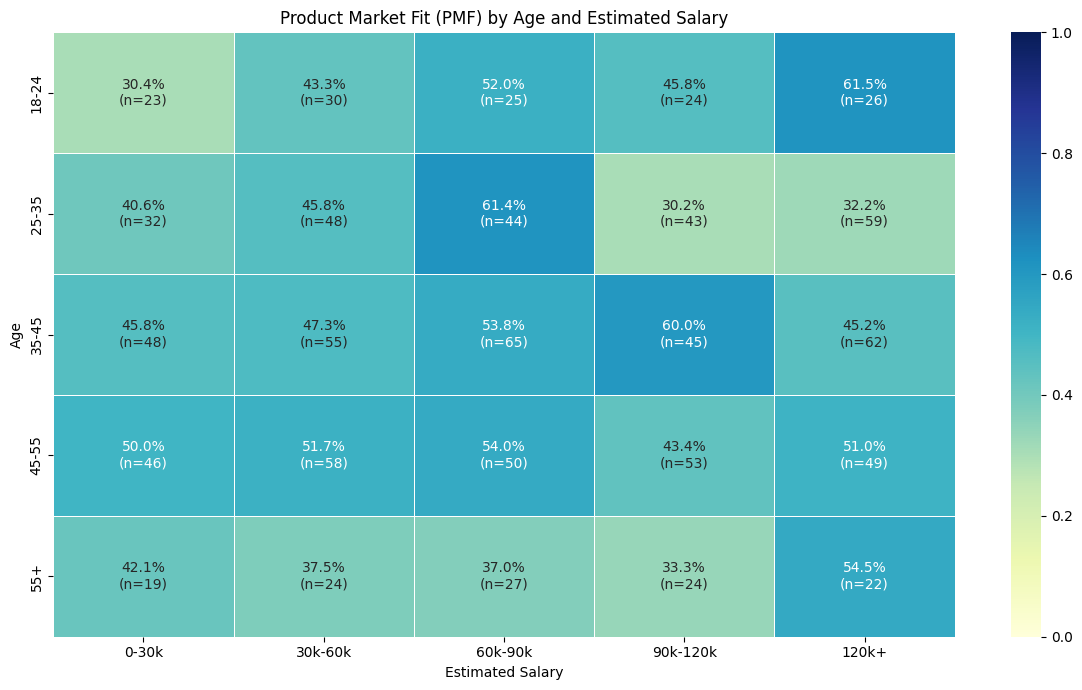

In [32]:
pmf_table = df_pmf.pivot_table(index='Age Group',
                              columns='Salary Group',
                              values='Purchased_Numeric',
                              aggfunc='mean',
                              observed=True)
counts = df_pmf.pivot_table(index='Age Group',
                              columns='Salary Group',
                              values='Purchased_Numeric',
                              aggfunc='size',
                              observed=True)
ann = (pmf_table*100).round(1).astype(str) + '%\n(n=' + counts.astype(str) + ')'
plt.figure(figsize=(12,7))
sns.heatmap(pmf_table,
           annot=ann,
           fmt='',
           cmap="YlGnBu",
           vmin=0, vmax=1,
           linewidths=.5)
plt.title('Product Market Fit (PMF) by Age and Estimated Salary')
plt.xlabel('Estimated Salary')
plt.ylabel('Age')
plt.tight_layout()
plt.show

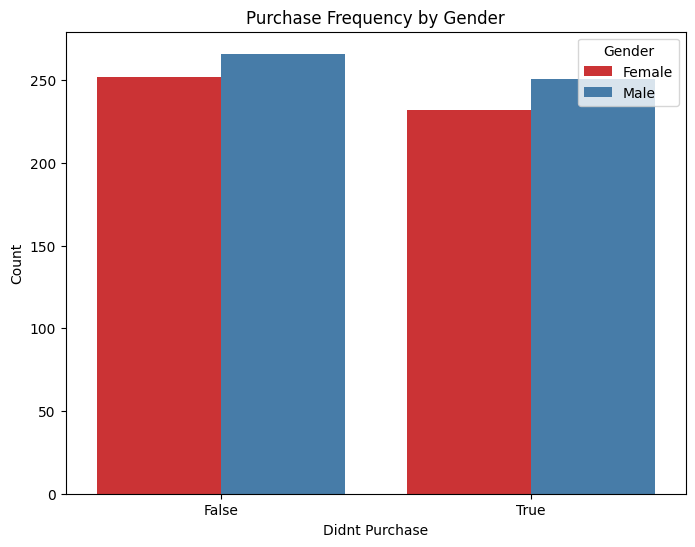

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

sns.countplot(
    x='is_not_purchased',
    hue='Gender',           # Split the bars by Gender
    data=data,
    palette='Set1'
)

plt.title('Purchase Frequency by Gender')
plt.xlabel('Didnt Purchase')
plt.ylabel('Count')
plt.show()


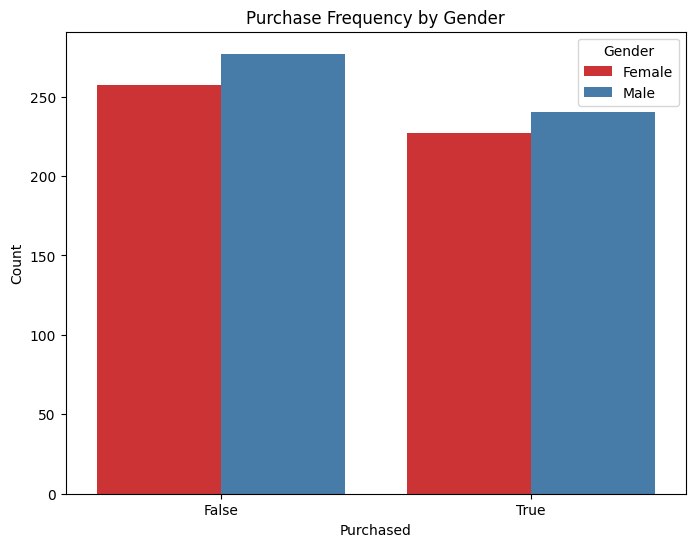

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

sns.countplot(
    x='is_purchased',
    hue='Gender',           # Split the bars by Gender
    data=data,
    palette='Set1'
)

plt.title('Purchase Frequency by Gender')
plt.xlabel('Purchased')
plt.ylabel('Count')
plt.show()


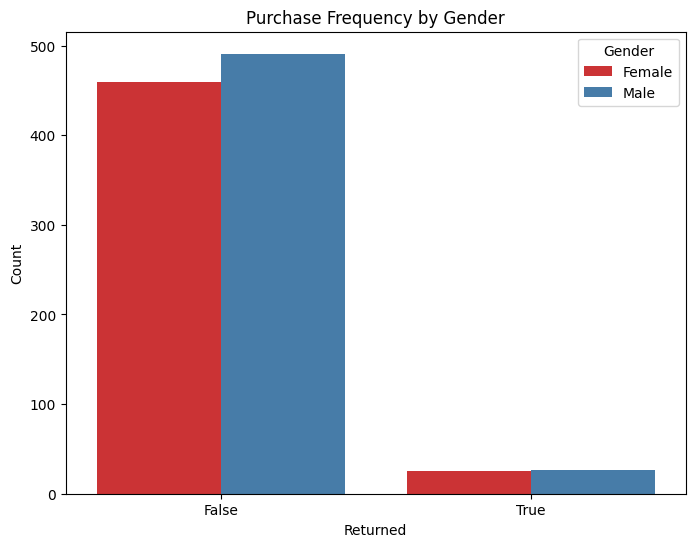

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

sns.countplot(
    x='is_returned',
    hue='Gender',           # Split the bars by Gender
    data=data,
    palette='Set1'
)

plt.title('Purchase Frequency by Gender')
plt.xlabel('Returned')
plt.ylabel('Count')
plt.show()


# 4.Prepare the Data


Apply any data transformations and explain what and why


In [33]:
X = pd.DataFrame({ # Split Data and gather wanted features
    "Age":     data.loc[:, "Age"],
    "EstimatedSalary":     data.loc[:, "EstimatedSalary"]
})

Y = df_pmf.loc[:, "Purchased_Numeric"]


df = pd.concat([X, Y], axis=1)
df = df.dropna()
X, Y = df[X.columns], df_pmf["Purchased_Numeric"]

# Create a binned version of Y
y_binned = pd.cut(Y, bins=4, labels=False)

X_train, X_test, y_train, y_test = train_test_split(
    X, Y, test_size=0.2, stratify=y_binned,  # Use the binned version for stratification
    random_state=42
)


# 5. Model the data
Using selected ML models, experment with your choices and describe your findings. Finish by selecting a Model to continue with


# 6. Fine Tune the Model

With the select model descibe the steps taken to acheve the best rusults possiable 


# 7. Present
In a customer faceing Document provide summery of finding and detail approach taken


# 8. Launch the Model System
Define your production run code, This should be self susficent and require only your model pramaters 


In [ ]:
def infrence(prams):
    results = m.run(prams)
    return results 